# Seasonality 고려하기 

계절적 자기회귀누적이동평균 (Seasonal AutoRegressive Integrated Moving Average; SARIMA)   
SARIMA $(p,d,q)(P,D,Q)_m$: 시계열을 예측할 때 주기적 패턴을 고려할 수 있는 또 다른 매개변수 집합을 추가하므로 ARIMA(p,d,q) 모델로는 가능하지 않은 예측을 할 수 있음.  

---
시계열에서 계절 패턴을 식별하는 방법을 확인하고 계절적 시계열을 예측하기 위한 SARIMA 모델을 적용. 
- ex) 이 모델을 적용하여 한 항공사의 월별 총 승객 수를 예측. 

In [1]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/refs/heads/master/data/air-passengers.csv')
df

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


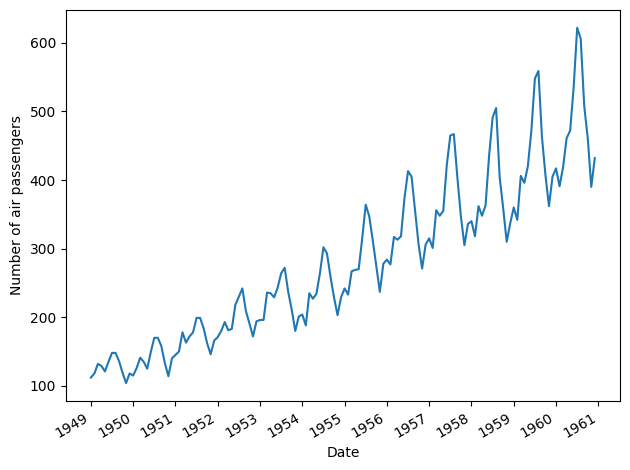

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()


도식: 계절적 패턴이 있음.
- 항공 승객 수는 연초와 연말에 낮고, 6/7/8월에 급증.

목표: 1년 동안의 월별 항공 승객 수를 예측.
- 항공사가 항공 승객 수를 예측하는 것은 항공권 가격을 더 잘 책정하고 특정 월의 수요를 충족하기 위해 항공편을 예약할 수 있도록 하기 위해 중요.

# 8.1 SARIMA $(p,d,q)(P,D,Q)_m$ 모델 살펴보기
SARIMA $(p,d,q)(P,D,Q)_m$ 는 **계절 매개변수**를 추가하여 ARIMA(p,d,q) 모델을 확장한 것.  
4가지의 새로운 매개변수
- (p,d,q): ARIMA(p,d,q)와 동일한 의미를 갖지만 계절에 따라 달라짐.
- $m$: 빈도 (계절적 주기당 관측 횟수)
    - 빈도: 주기당 관측 횟수; 데이터 집합에 따라 달라짐.
    - 매년, 분기, 월, 주 단위로 기록된 데이터의 경우 주기의 길이는 1년으로 간주.
        - 매년 기록된 경우, 1년에 관찰이 한 번만 있으므로 m = 1
        - 분기별 기록된 경우, m = 4
        - 월별로 기록된 경우, m = 12
        - 주간으로 기록된 경우, m = 52
    - 일별, 또는 일 하위 시간 단계로 수집되는 경우
        - 일별 데이터는 주간 계절성. m = 7 (1주는 7일이니까)
        - 연간 계절성: m = 365
    - 일별 데이터와 일 하위 시간 단계 데이터는 서로 다른 주기를 가질 수 있고, 다른 빈도 m을 가질 수 있음. 
- (P,D,Q): ARIMA(p,d,q) 모델의 p,d,q 매개변수에 계절적으로 상응하는 값. 
    - P: 계절적 AR(P) 프로세스의 차수
    - D: 계절적 적분 차수
    - Q: 계절적 MA(Q) 프로세스의 차수

**SARIMA $(p,d,q)(0,0,0)_m$ = ARIMA(p,d,q)**

---
예시)  
$m$ = 12  
P = 2이면, m의 배수인 지연에 대해 두 개의 과거 시계열값을 포함한다는 뜻.
- $y_{t-12}$와 $y_{t-24}$의 값을 포함.  

D = 1이면, 계절적 차분으로 시계열을 정상적 상태로 만들 수 있음.  
- $y'=y_t-y_{t-12}$

Q = 2라면, m의 배수인 지연에 대한 과거 오차 항을 포함해야 하므로 오차 $\epsilon_{t-12}$ 와 $\epsilon_{t-24}$가 포함.

항공사의 월별 총 항공 승객 데이터 집합에 이를 적용해보자.

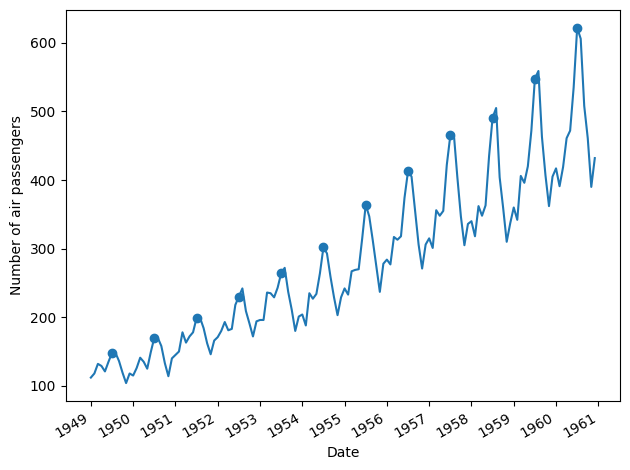

In [ ]:
# 매년의 7월에 표시
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'], markevery=np.arange(6, 145, 12), marker='o')
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

그림 해석:
- 매해, 7월에 항공 승객수가 가장 많다.

# 8.2 시계열에서 계절별 패턴 식별
그러면 계절성을 어떻게 식별하는가?
- 주로 도식화 하는것만으로도 주기적인 패턴 관찰 가능.
- 또는 **시계열 분해**.
    - 시계열을 추세 구성요소, 계절적 구성요소, 잔차의 세 가지 주요 구성요소로 분리하는 통계 작업.

추세 구성요소: 시계열의 <u>장기적인 변화</u>를 나타냄. 이 구성요소는 시간이 지남에 따라 증가, 또는 감소하는 시계열과 관련.  
계절적 구성요소: 시계열의 계절적 패턴. 일정 기간 동안 발생하는 <u>반복적인 변동</u>을 나타냄.  
잔차나 노이즈: 추세 또는 계절적 구성요소로 <u>설명할 수 없는 불규칙성</u>을 나타냄.  

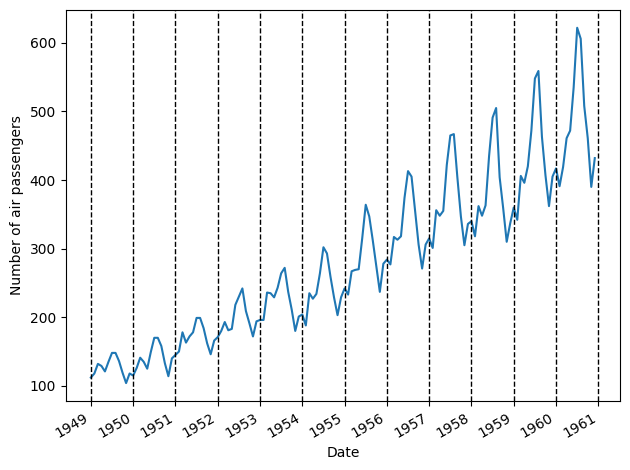

In [4]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
for i in np.arange(0, 145, 12):
    ax.axvline(x=i, linestyle='--', color='black', linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()


윗 그림에서는, 
- 매년 중반에 피크 발생; 매년 초와 말에는 매우 유사한 패턴.
- 항공 승객수가 6,7,8월에 많게 기록되고, 11,12,1월에는 승객수가 줄어드는 패턴. 

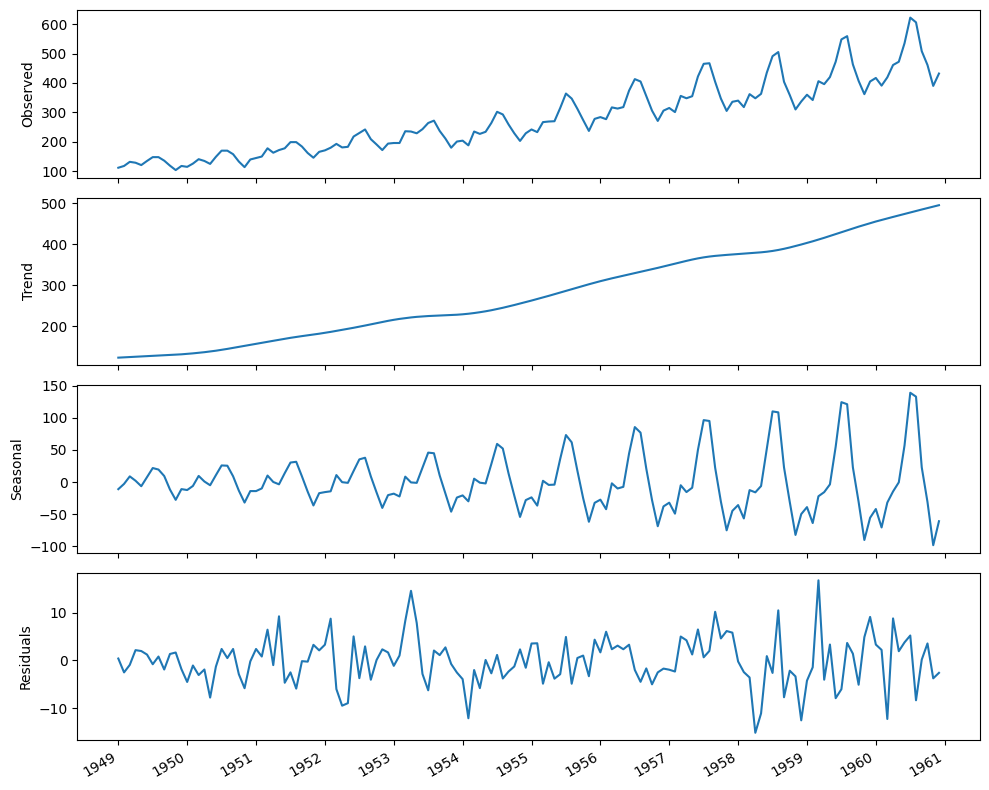

In [8]:
from statsmodels.tsa.seasonal import STL

decomposition = STL(df['Passengers'], period = 12).fit()
# 주기는 빈도 m; 월별 데이터이므로 주기는 12.

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows = 4, ncols = 1, sharex = True, figsize = (10, 8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

그림 해설:
- 첫번째: 관찰된 데이터
- 두번째: 추세 구성요소; 시간이 지남에 따라 항공 승객 수가 증가
- 세번째: 계절적 구성요소; 시간이 지남에 따라 반복되는 패턴을 명확하게 볼 수 있음
- 네번째: 잔차; 추세 또는 계절적 구성요소로 설명할 수 없는 데이터의 변동  

계절적 패턴이 없는 시계열 상황:
- 분해 절차로 얻은 계절적 구성요소가 0에서 평평한 수평선.

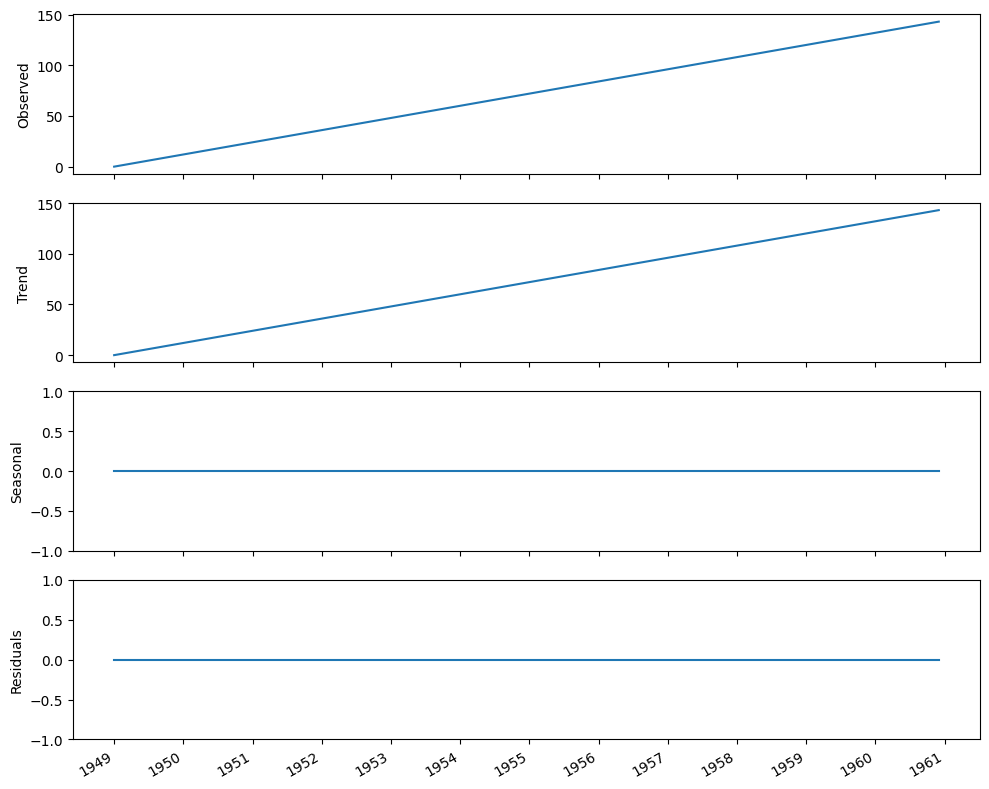

In [9]:
linear_ts = np.arange(0, 144, 1)

decomposition = STL(linear_ts, period=12).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')
ax3.set_ylim(-1, 1)

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')
ax4.set_ylim(-1, 1)

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

맨위: 관측된 데이터; 완벽한 선형 수열을 시뮬레이션.  
두번째: 추세; 시간이 지남에 따라 선형적으로 증가하기에 관측된 데이터와 동일할 것으로 예상.
세번째: 계절적; 계절적 패턴이 없기 때문에 계절적 구성요소는 0에서 평평한 수평선  
네번째: 잔차; 잔차 = 0 --> 완벽한 선형 수열을 시뮬레이션 했음.  

**시계열에서는 계절성을 식별하는 통계적 테스트는 없음.**

# 8.3 월간 항공 승객 수 예측

ARIMA와 동일하게 차분을 얼만큼 했는지 d를 결정하는 것까지는 똑같음.  
그 이후 계절적 차분을 적용해 시계열을 정상적 상태로 만들 수 있음 (D: 계절적 차분을 적용한 최소 횟수)

그 다음 SARIMA는 계절적 자기회귀 & 계절적 이동평균과정의 차수를 통합할 수 있으니 p,q,P,Q에 대한 가능한 값의 범위를 지정.  

똑같이 AIC가 가장 낮은 모델을 선택하고 잔차 분석을 수행.

![alt text](Screenshots/8.7.png)

## 8.3.1 ARIMA(p,d,q) 모델을 사용해 예측

월별 총 항공 승객 수 예측

우선 ARIMA(p,d,q) 모델을 사용해 데이터 집합을 모델링. 이러면 SARIMA(p,d,q)$(P,D,Q)_m$ 모델과 성능 비교 가능

In [10]:
from statsmodels.tsa.stattools import adfuller

ad_fuller_result = adfuller(df['Passengers'])

print(f'ADF Stats: {ad_fuller_result[0]}')
print(f'p-val: {ad_fuller_result[1]}')

ADF Stats: 0.8153688792060447
p-val: 0.9918802434376409


귀무가설 기각할 수 없음 --> 수열은 비정상적이라는 뜻.

In [11]:
df_diff = np.diff(df['Passengers'], n=1) #1차 차분

ad_fuller_result = adfuller(df_diff)

print(f'ADF Stats: {ad_fuller_result[0]}')
print(f'P-val: {ad_fuller_result[1]}')

ADF Stats: -2.8292668241699794
P-val: 0.05421329028382823


아직도 귀무가설 기각할 수 없음

In [12]:
df_diff2 = np.diff(df_diff, n = 1)

ad_fuller_result = adfuller(df_diff2)

print(f'ADF Stats: {ad_fuller_result[0]}')
print(f'P-val: {ad_fuller_result[1]}')

ADF Stats: -16.38423154246855
P-val: 2.732891850013926e-29


이제 귀무가설 기각할 수 있음. 수열은 정상적인 상태라고 간주할 수 있음.  
d = 2  
이제 매개변수 p,q에 가능한 값의 범위를 정의하고 모든 고유한 ARIMA(p,d,q) 모델을 피팅. 여기서는 0-12 사이의 범위를 선태갛여 ARIMA 모델이 12개의 시간 단계를 거슬러 올라가도록.  
데이터는 매월 측정되고 계절적 요인이 있다는 것을 알고 있으니 특정 연도 1월의 항공 승객 수가 다음연도 1월의 항공 승객 수를 예측할 수 있다는 가설을 세울 수 있음. 그래서 p & q 값을 0-12 사이에서 다양하게 적용.  
마지막으로, ARIMA 모델로 작업중이니 P, D, Q를 0으로 설정. 다음 코드에서 m에 해당하는 매개변수 s를 사용하는 것에 유의. (statsmodels 에서 SARIMA는 m 대신 s 사용)

In [ ]:
from itertools import product
# 계절적 정보 포착 위해 p 와 q 값으로 0에서 12까지 다양하게 적용.
ps = range(0,13,1)
qs = range(0,13,1)
Ps = [0] # ARIMA 모델을 사용하고 있으니 P와 Q를 0으로 설정; 아직 계절성 AR/MA (P,Q) 탐색 안 하고 있음.
Qs = [0]

d = 2 # 매개변수 d를 시계열이 정상적이 되도록 차분을 한 횟수로 설정
D = 0 #ARIMA 모델로 하니까 D = 0
s = 12

ARIMA_order_list = list(product(ps, qs, Ps, Qs))

ARIMA 사용하는데 P,D,Q,m 설정한 이유: 다음 절에서 재사용할 optimize_SARIMA 함수를 정의하기 위해.  
SARIMA(p,d,q)(0,0,0)$_m$ 모델은 ARIMA(p,d,q) 모델과 동일하므로 P,D,Q를 0으로 설정.

In [16]:
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMA(endog: Union[pd.Series, list], order_list: list, 
                   d: int, D: int, s: int) -> pd.DataFrame: #endog: 관측된 시계열 데이터
    # 여기서 s은 SARIMA의 m
    # 고유 (p,q) 조합들의 목록, 적분 차수 d를 입력받는다. 
    results = [] 

    for order in tqdm_notebook(order_list): #모든 (p,q) 조합의 목록에 대해 for 루프. tqdm_notebook을 통해 진행률 표시.
        try:
            model = SARIMAX(endog, 
                            order = (order[0], d, order[1]),
                            seasonal_order=(order[2], D, order[3], s), 
                            simple_differencing=False).fit(disp = False) #SARIMAX 함수를 사용해 ARMA(p,d,q) 모델 피팅. 
                            #차분이 되지 않도록 simple_differencing을 False.
                            # 콘솔에 상태 메시지 안 나오도록 disp = False.
                            # order = (p,d,P,D)
        except:
            continue

        aic = model.aic #모델의 aic 계산.
        results.append([order,aic]) #결과 목록에 (p,q) 조합과 AIC를 튜플로 추가.

    result_df = pd.DataFrame(results) #(p,q) 조합과 AIC를 DataFrame에 저장
    result_df.columns = ['(p,q,P,Q)', 'AIC'] #DataFrame의 열에 레이블 지정

    # ascending order as lower AIC is better
    result_df = result_df.sort_values(by = 'AIC', ascending = True).reset_index(drop = True) #AIC값을 기준으로 오름차순 정렬.

    return result_df

훈련 집합 생성해 함수 실행하고 AIC 가장 낮은 ARIMA 모델 얻기

In [17]:
train = df['Passengers'][:-12]

ARIMA_result_df = optimize_SARIMA(train, ARIMA_order_list, d, D, s)
ARIMA_result_df

/var/folders/3z/5gfy93qs7vz0g17fs_bg32xr0000gn/T/ipykernel_27720/1699955399.py:11: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list): #모든 (p,q) 조합의 목록에 대해 for 루프. tqdm_notebook을 통해 진행률 표시.


  0%|          | 0/169 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py

,"(p,q,P,Q)",AIC
0,"(11, 3, 0, 0)",1016.981488
1,"(11, 4, 0, 0)",1019.000658
2,"(11, 5, 0, 0)",1020.343614
3,"(12, 0, 0, 0)",1020.816005
4,"(11, 1, 0, 0)",1021.012967
...,...,...
164,"(5, 0, 0, 0)",1281.732157
165,"(3, 0, 0, 0)",1300.282335
166,"(2, 0, 0, 0)",1302.913196
167,"(1, 0, 0, 0)",1308.152194


AIC가 가장 낮은 모델: SARIMA(11,2,3)(0,0,0)$_12$ --> ARIMA(11,2,3)과 동일  
p = 11이므로, AIC가 가장 낮은 모델은 수열의 과거 11개 값을 고려하기 때문에 0에서 12까지 다양하게 적용해본 것이 모델에 유리.

0은 무슨 뜻?
- p = 0이라면, 자기회귀 (과거 관측값) 항 없이 모델링. 시계열 이번값이 과거값에 직접 의존 안 함.
- q = 0이라면, 이동평균 (과거 오차) 항 없음
- p = 0, q = 0이라면, ARIMA(0,d,0). d=2번 차분만 적용된 상태; AR/MA 구조 전혀 없는 모델 (순수 Random Walk)